# FER-2013: Test Set Analysis

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

REPORTS = Path("../reports")
LABELS = ("angry", "disgust", "fear", "happy", "sad", "surprise", "neutral")

preds = np.load(REPORTS / "test_preds.npy")
targets = np.load(REPORTS / "test_targets.npy")
probs = np.load(REPORTS / "test_probs.npy")
confusion = np.load(REPORTS / "test_confusion.npy")
metrics = json.loads((REPORTS / "test_metrics.json").read_text())

print(f"test samples: {len(preds)}")
print(f"accuracy: {metrics['accuracy']:.4f}")
print(f"macro_f1: {metrics['macro_f1']:.4f}")
print(f"mean confidence: {probs.max(axis=1).mean():.4f}")

test samples: 3589
accuracy: 0.7116
macro_f1: 0.7113
mean confidence: 0.8895


## Per-class report

In [3]:
report = classification_report(
    targets, preds, target_names=LABELS, digits=3, output_dict=True, zero_division=0
)
df = pd.DataFrame(report).T
df = df.loc[list(LABELS) + ["accuracy", "macro avg", "weighted avg"]]
df[["precision", "recall", "f1-score"]].round(3)

,precision,recall,f1-score
angry,0.647,0.635,0.641
disgust,0.854,0.745,0.796
fear,0.624,0.549,0.584
happy,0.890,0.879,0.884
sad,0.568,0.572,0.570
surprise,0.821,0.815,0.818
neutral,0.644,0.733,0.686
accuracy,0.712,0.712,0.712
macro avg,0.721,0.704,0.711
weighted avg,0.713,0.712,0.711


## Confusion matrix (row-normalized)

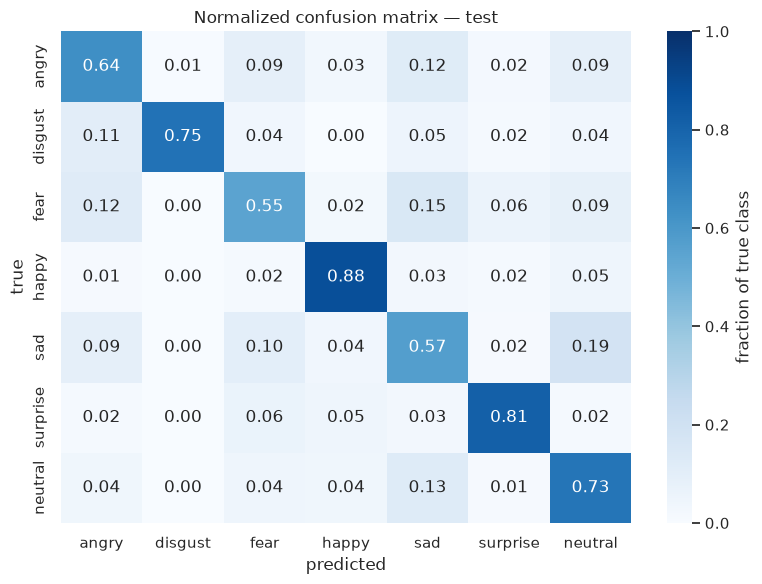

In [4]:
cm_norm = confusion / confusion.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar_kws={"label": "fraction of true class"},
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Normalized confusion matrix — test")
plt.tight_layout()
plt.show()

## F1 per class

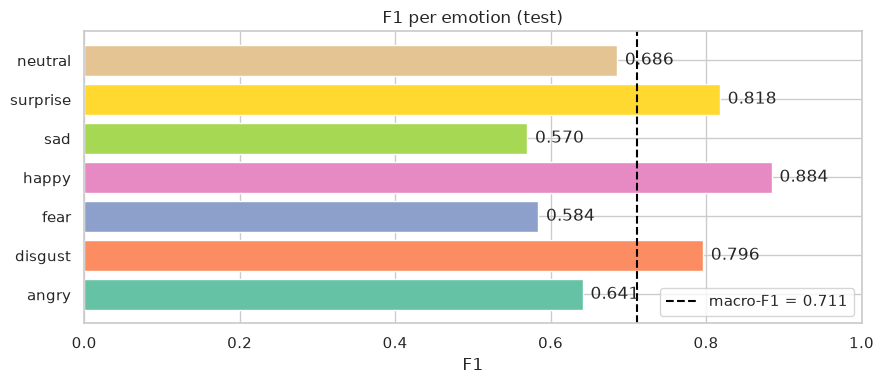

In [11]:
f1_per_class = [report[name]["f1-score"] for name in LABELS]

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette("Set2", len(LABELS))
bars = ax.barh(LABELS, f1_per_class, color=colors)
ax.axvline(
    metrics["macro_f1"],
    color="black",
    linestyle="--",
    label=f"macro-F1 = {metrics['macro_f1']:.3f}",
)
ax.set_xlim(0, 1)
ax.set_xlabel("F1")
ax.set_title("F1 per emotion (test)")
for bar, v in zip(bars, f1_per_class):
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.3f}", va="center")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Top confusion pairs

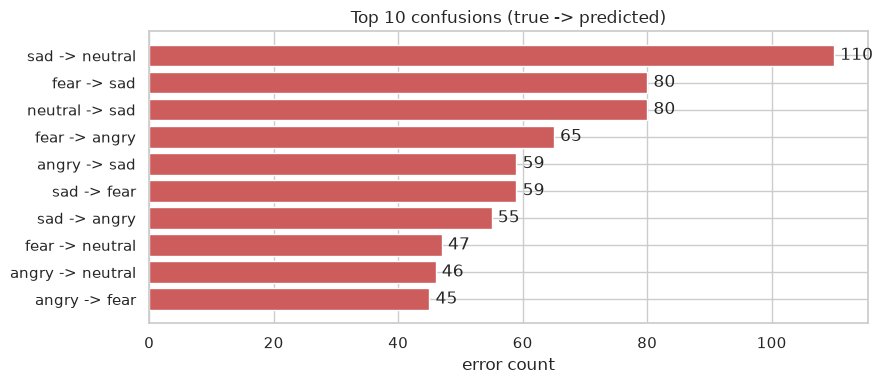

In [13]:
cm = confusion.copy()
np.fill_diagonal(cm, 0)
pairs = []
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        if cm[i, j] > 0:
            pairs.append((LABELS[i], LABELS[j], int(cm[i, j])))
pairs.sort(key=lambda x: -x[2])
top = pairs[:10]

fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{a} -> {b}" for a, b, _ in top]
counts = [c for _, _, c in top]
ax.barh(labels[::-1], counts[::-1], color="indianred")
ax.set_xlabel("error count")
ax.set_title("Top 10 confusions (true -> predicted)")
for i, v in enumerate(counts[::-1]):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.show()

## Most confident misclassifications

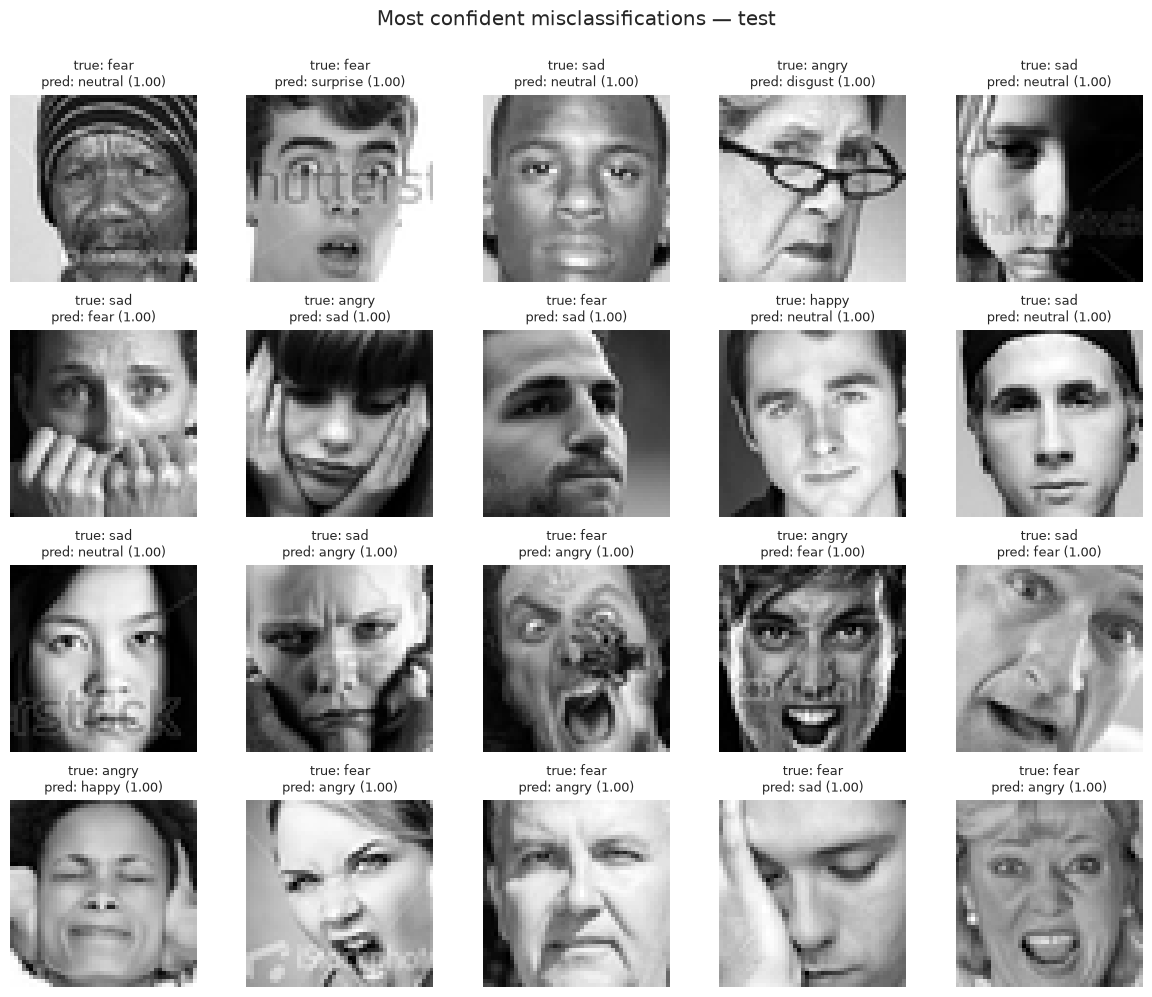

In [15]:
X_test = np.load("../data/processed/X_test.npy")

wrong = preds != targets
wrong_idx = np.where(wrong)[0]
max_conf = probs[wrong_idx].max(axis=1)
order = wrong_idx[np.argsort(-max_conf)]

n_show = 20
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, idx in zip(axes.flat, order[:n_show]):
    ax.imshow(X_test[idx], cmap="gray")
    t = LABELS[targets[idx]]
    p = LABELS[preds[idx]]
    conf = probs[idx].max()
    ax.set_title(f"true: {t}\npred: {p} ({conf:.2f})", fontsize=9)
    ax.axis("off")
plt.suptitle("Most confident misclassifications — test", y=0.995)
plt.tight_layout()
plt.show()

## Confidence distribution

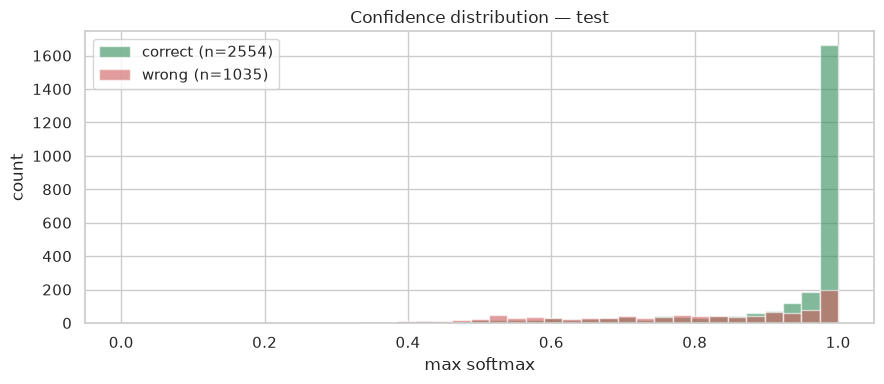

correct mean: 0.9310, median: 0.9943
wrong mean: 0.7872, median: 0.8264
wrong with confidence > 0.8: 555 (53.6%)


In [16]:
correct_conf = probs[preds == targets].max(axis=1)
wrong_conf = probs[preds != targets].max(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 40)
ax.hist(correct_conf, bins=bins, alpha=0.6, label=f"correct (n={len(correct_conf)})", color="seagreen")
ax.hist(wrong_conf, bins=bins, alpha=0.6, label=f"wrong (n={len(wrong_conf)})", color="indianred")
ax.set_xlabel("max softmax")
ax.set_ylabel("count")
ax.set_title("Confidence distribution — test")
ax.legend()
plt.tight_layout()
plt.show()

print(f"correct mean: {correct_conf.mean():.4f}, median: {np.median(correct_conf):.4f}")
print(f"wrong mean: {wrong_conf.mean():.4f}, median: {np.median(wrong_conf):.4f}")
print(f"wrong with confidence > 0.8: {(wrong_conf > 0.8).sum()} ({100 * (wrong_conf > 0.8).mean():.1f}%)")